# 🔗 Innovation Relatedness and Density Analysis

In Economic Complexity, **Relatedness** (often measured as **Density**) quantifies how close a country is to a new field based on its existing innovation capabilities.

- **Density**: Measures the proximity of a country's current specialized fields to a specific new field. High density indicates that a country already possesses many of the related capabilities needed to succeed in that field.
- **Strategic Opportunities**: We look for fields where a country has **High Density** but no **Comparative Advantage (RCA < 1)** yet. These are "easy wins" or natural next steps for diversification.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ecomplexity import ecomplexity
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})
print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load Data
We will load the **Production (P)** dimension for the year **2023**.

In [13]:
# Load mapping files
fields = pd.read_parquet('data/fields.parquet')
units = pd.read_parquet('data/units.parquet')

# Load output data
outputs = pd.read_parquet('data/outputs.parquet')

# Filter for Production dimension in 2023
data_2023 = outputs[(outputs['Period'] == 2023) & (outputs['Dimension'] == 'P')].copy()
print(f"Selected {len(data_2023):,} rows for Production in 2023")

Selected 164,642 rows for Production in 2023


## 2. Calculate E-Complexity Indices
The `ecomplexity` function computes RCA, ECI, PCI, and crucially for this analysis, **Density**.

In [14]:
trade_cols = {'time': 'Period', 'loc': 'Unit', 'prod': 'Field ID', 'val': 'Outputs (Fractional)'}
complexity_results = ecomplexity(data_2023[trade_cols.values()], trade_cols)

# Merge with field names for better readability
complexity_results = complexity_results.merge(
    fields[['Field ID', 'Field Name', 'Dimension Name']], 
    on='Field ID', 
    how='left'
)

print("✅ Complexity and Density calculated")
complexity_results[['Unit', 'Field Name', 'rca', 'density', 'pci']].head()

2023
Percentage of pairs compared that meet log-supermodularity condition: 43.84%
✅ Complexity and Density calculated


,Unit,Field Name,rca,density,pci
0,AD,Live Equines,1.593356,0.130620,1.282902
1,AD,Live Cattle,0.000000,0.108141,-0.028798
2,AD,Live Pigs,0.000000,0.103336,2.610128
3,AD,Live Sheep and Goats,0.099631,0.102807,-1.637211
4,AD,Live Poultry,0.000000,0.106955,0.209338


## 3. Identify Strategic Opportunities for a Country
Let's focus on **Chile (CL)** as an example to see which innovation fields are most "related" to its current profile but haven't been developed yet (RCA < 1).

In [15]:
iso = 'CL'
country_name = "Chile"

chile_data = complexity_results[complexity_results['Unit'] == iso].copy()

# Filter for fields where Chile does NOT yet have a Comparative Advantage (RCA < 1)
opps = chile_data[chile_data['rca'] < 1].sort_values('density', ascending=False)

print(f"Top 10 Strategic Opportunities for {country_name} (Highest Density, RCA < 1):")
opps[['Field Name', 'density', 'pci', 'rca']].head(10)

Top 10 Strategic Opportunities for Chile (Highest Density, RCA < 1):


,Field Name,density,pci,rca
29469,Aluminum Ore,0.179805,-3.521350,0.000177
29465,Manganese Ore,0.172323,-3.299590,0.000000
29463,Other Minerals,0.163869,-3.621762,0.017623
29326,Crustaceans,0.163482,-2.473582,0.660655
29484,Crude Oil,0.159794,-3.320079,0.003299
29486,Petroleum Gas,0.157640,-2.400063,0.062985
29385,Other Oil Seeds,0.153874,-2.609057,0.344895
29353,Dried Legumes,0.153606,-2.647265,0.116799
29412,Cocoa Beans,0.153136,-3.441951,0.001108
29703,Raw Cotton,0.151375,-3.446934,0.000077


## 4. Visualizing the Opportunity Space
We can plot **Density vs. Complexity (PCI)**. 
- **Top-Right (High Density, High PCI)**: Strategic sweet spot (Related and Complex).
- **Bottom-Right (Low Density, High PCI)**: Long-term bets (Complex but unrelated to current capabilities).

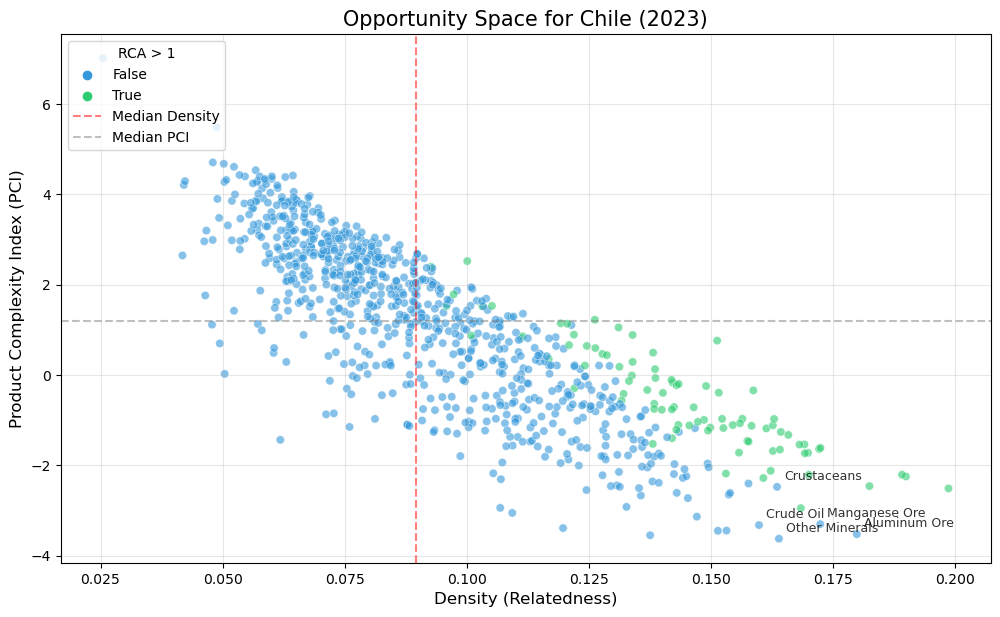

In [16]:
plt.figure(figsize=(12, 7))

# All products for Chile
chile_data['is_specialized'] = chile_data['rca'] > 1
sns.scatterplot(data=chile_data, x='density', y='pci', hue='is_specialized', alpha=0.6, palette={True: '#2ecc71', False: '#3498db'})

plt.axvline(chile_data['density'].median(), color='red', linestyle='--', alpha=0.5, label='Median Density')
plt.axhline(chile_data['pci'].median(), color='gray', linestyle='--', alpha=0.5, label='Median PCI')

plt.title(f'Opportunity Space for {country_name} (2023)', fontsize=15)
plt.xlabel('Density (Relatedness)', fontsize=12)
plt.ylabel('Product Complexity Index (PCI)', fontsize=12)
plt.legend(title='RCA > 1', loc='upper left')

# Label top 5 opportunities
top_5 = opps.head(5)
for i, row in top_5.iterrows():
    plt.annotate(row['Field Name'], (row['density'], row['pci']), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8)

plt.grid(True, alpha=0.3)
plt.show()

## 5. Summary Statistics of Density
Let's compare the average density of fields where countries have RCA > 1 vs where they don't. Usually, countries specialize in fields with higher average density.

In [17]:
density_compare = complexity_results.groupby(complexity_results['rca'] > 1)['density'].mean()
print("Average Density by Specialization Status:")
print(density_compare)

Average Density by Specialization Status:
rca
False    0.112469
True     0.280686
Name: density, dtype: float64
